In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('amazonreviews.tsv', sep='\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [8]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [11]:
print(f"Initial number of rows: {len(df)}")
# 1. Identify and count the number of duplicate rows
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

Initial number of rows: 10000
Number of duplicate rows found: 0


In [12]:
df = df.drop_duplicates(keep='first')

In [17]:
print(f"Number of rows after removing duplicates: {len(df)}")
print('\nDataFrame Info after removing duplicates:')

Number of rows after removing duplicates: 10000

DataFrame Info after removing duplicates:


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [21]:
print('Converting \'review\' column to lowercase...')
df['review'] = df['review'].str.lower()

print('\nFirst 5 rows of the DataFrame after lowercasing:')
print(df.head())

Converting 'review' column to lowercase...

First 5 rows of the DataFrame after lowercasing:
  label                                             review
0   pos  stuning even for the non-gamer: this sound tra...
1   pos  the best soundtrack ever to anything.: i'm rea...
2   pos  amazing!: this soundtrack is my favorite music...
3   pos  excellent soundtrack: i truly like this soundt...
4   pos  remember, pull your jaw off the floor after he...


Sentiment Distribution:
label
neg    5097
pos    4903
Name: count, dtype: int64


C:\Users\yaram\AppData\Local\Temp\ipykernel_19912\1701650821.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


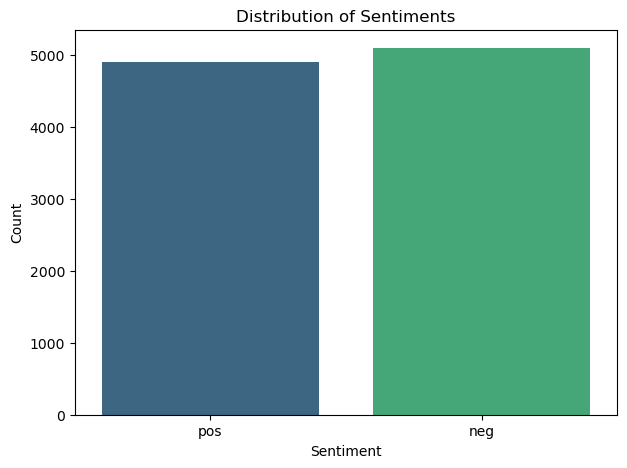

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count the occurrences of each unique value in the 'label' column
sentiment_counts = df['label'].value_counts()

# 2. Print the sentiment counts
print("Sentiment Distribution:")
print(sentiment_counts)

# 3. Create a bar plot to visualize the distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis')

# 4. Set the title of the plot
plt.title('Distribution of Sentiments')

# 5. Label the x-axis as 'Sentiment' and the y-axis as 'Count'
plt.xlabel('Sentiment')
plt.ylabel('Count')

# 6. Display the plot
plt.show()

In [24]:
!pip install wordcloud

In [25]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
print("Libraries 'matplotlib.pyplot' and 'wordcloud' imported successfully.")

Libraries 'matplotlib.pyplot' and 'wordcloud' imported successfully.


Generating word cloud for all reviews...


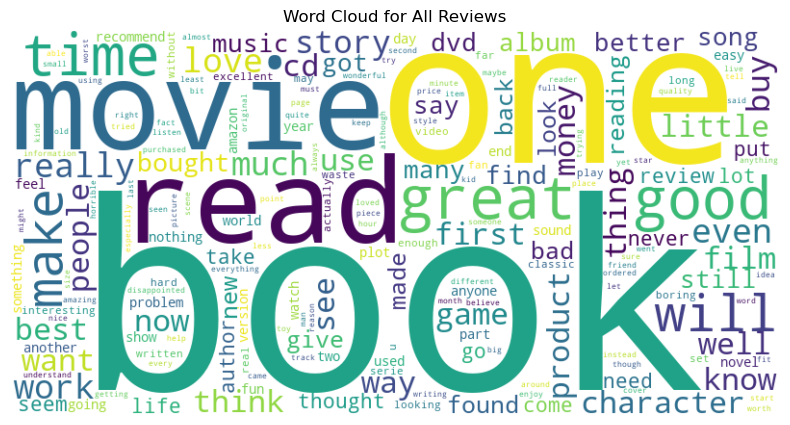

In [27]:
print('Generating word cloud for all reviews...')
all_reviews_text = ' '.join(df['review'].dropna().tolist())
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(all_reviews_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for All Reviews')
plt.show()

Generating word cloud for positive reviews...


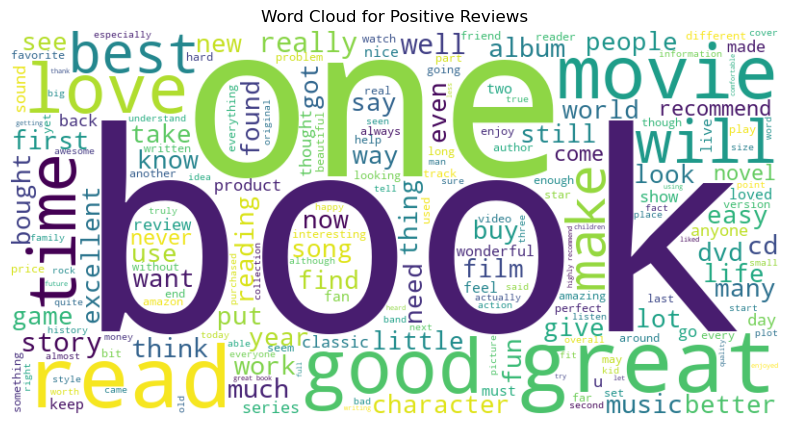

In [28]:
print('Generating word cloud for positive reviews...')
positive_reviews_text = ' '.join(df[df['label'] == 'pos']['review'].dropna().tolist())
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

Generating word cloud for negative reviews...


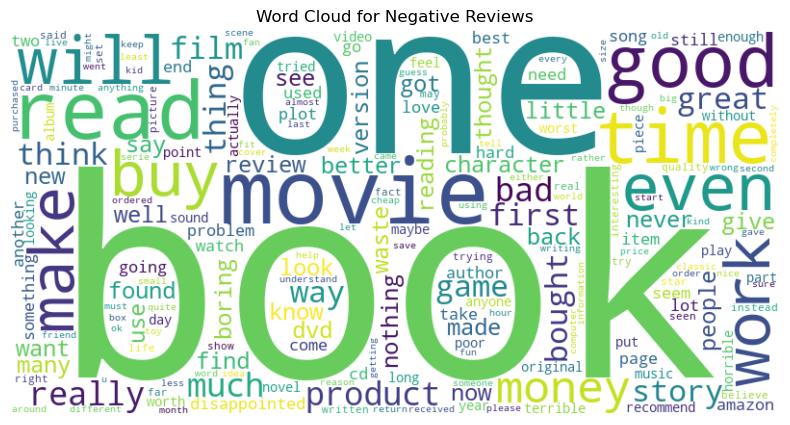

Word clouds generated successfully.


In [29]:
print('Generating word cloud for negative reviews...')
negative_reviews_text = ' '.join(df[df['label'] == 'neg']['review'].dropna().tolist())
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

print('Word clouds generated successfully.')

In [32]:
!pip install nltk

In [34]:
import nltk

print("Downloading NLTK 'punkt' and 'stopwords' corpora...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print("NLTK 'punkt' and 'stopwords' corpora downloaded successfully.")

NLTK 'punkt' and 'stopwords' corpora downloaded successfully.


In [38]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt_tab')
import string

print("Importing nltk.tokenize.word_tokenize, nltk.corpus.stopwords, and string...")

# Create a set of English stopwords
stop_words = set(stopwords.words('english'))

# Define a function for text preprocessing
def preprocess_text(text):
    if isinstance(text, str):
        # Tokenize the text
        tokens = word_tokenize(text)
        # Convert to lowercase, remove punctuation and stopwords
        cleaned_tokens = [word.lower() for word in tokens if word.isalpha() and word.lower() not in stop_words]
        return cleaned_tokens
    return []

print("Applying text preprocessing to the 'review' column...")
df['processed_review'] = df['review'].apply(preprocess_text)

print("First 5 rows of the DataFrame with 'processed_review' column:")
print(df[['review', 'processed_review']].head())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yaram\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Importing nltk.tokenize.word_tokenize, nltk.corpus.stopwords, and string...
Applying text preprocessing to the 'review' column...
First 5 rows of the DataFrame with 'processed_review' column:
                                              review  \
0  stuning even for the non-gamer: this sound tra...   
1  the best soundtrack ever to anything.: i'm rea...   
2  amazing!: this soundtrack is my favorite music...   
3  excellent soundtrack: i truly like this soundt...   
4  remember, pull your jaw off the floor after he...   

                                    processed_review  
0  [stuning, even, sound, track, beautiful, paint...  
1  [best, soundtrack, ever, anything, reading, lo...  
2  [amazing, soundtrack, favorite, music, time, h...  
3  [excellent, soundtrack, truly, like, soundtrac...  
4  [remember, pull, jaw, floor, hearing, played, ...  


In [39]:
from collections import Counter

# Filter for positive reviews and join tokens
print("Filtering for positive reviews and joining tokens...")
positive_reviews_tokens = [token for sublist in df[df['label'] == 'pos']['processed_review'].tolist() for token in sublist]

# Filter for negative reviews and join tokens
print("Filtering for negative reviews and joining tokens...")
negative_reviews_tokens = [token for sublist in df[df['label'] == 'neg']['processed_review'].tolist() for token in sublist]

# Count word frequencies for positive reviews
print("Counting word frequencies for positive reviews...")
positive_word_counts = Counter(positive_reviews_tokens)

# Count word frequencies for negative reviews
print("Counting word frequencies for negative reviews...")
negative_word_counts = Counter(negative_reviews_tokens)

# Display the top 20 most common words for positive reviews
print("\nTop 20 Most Common Words in Positive Reviews:")
for word, count in positive_word_counts.most_common(20):
    print(f"{word}: {count}")

# Display the top 20 most common words for negative reviews
print("\nTop 20 Most Common Words in Negative Reviews:")
for word, count in negative_word_counts.most_common(20):
    print(f"{word}: {count}")

Filtering for positive reviews and joining tokens...
Filtering for negative reviews and joining tokens...
Counting word frequencies for positive reviews...
Counting word frequencies for negative reviews...

Top 20 Most Common Words in Positive Reviews:
book: 3345
great: 2102
one: 1863
good: 1644
read: 1563
like: 1275
movie: 1093
would: 1002
love: 906
time: 886
well: 853
really: 829
best: 805
get: 797
story: 720
first: 711
much: 653
cd: 606
music: 564
also: 562

Top 20 Most Common Words in Negative Reviews:
book: 3223
one: 2040
would: 1600
like: 1553
movie: 1488
read: 1196
good: 1144
get: 1144
time: 1043
even: 904
could: 880
buy: 817
really: 782
much: 773
bad: 753
money: 751
first: 744
better: 660
great: 636
product: 625


# Model Deploment

In [40]:
print("Converting processed review tokens into single strings...")
df['processed_review_str'] = df['processed_review'].apply(lambda x: ' '.join(x))

print("First 5 rows of the DataFrame with 'processed_review_str' column:")
print(df[['review', 'processed_review', 'processed_review_str']].head())

Converting processed review tokens into single strings...
First 5 rows of the DataFrame with 'processed_review_str' column:
                                              review  \
0  stuning even for the non-gamer: this sound tra...   
1  the best soundtrack ever to anything.: i'm rea...   
2  amazing!: this soundtrack is my favorite music...   
3  excellent soundtrack: i truly like this soundt...   
4  remember, pull your jaw off the floor after he...   

                                    processed_review  \
0  [stuning, even, sound, track, beautiful, paint...   
1  [best, soundtrack, ever, anything, reading, lo...   
2  [amazing, soundtrack, favorite, music, time, h...   
3  [excellent, soundtrack, truly, like, soundtrac...   
4  [remember, pull, jaw, floor, hearing, played, ...   

                                processed_review_str  
0  stuning even sound track beautiful paints sene...  
1  best soundtrack ever anything reading lot revi...  
2  amazing soundtrack favorite music 

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("Splitting data into training and testing sets...")
# Split the DataFrame into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['processed_review_str'], df['label'], test_size=0.2, random_state=42)

print("Initializing TfidfVectorizer...")
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

print("Fitting TfidfVectorizer to training data and transforming both training and testing data...")
# Fit the vectorizer to the training data and transform both training and testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF features created successfully.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Splitting data into training and testing sets...
Initializing TfidfVectorizer...
Fitting TfidfVectorizer to training data and transforming both training and testing data...
TF-IDF features created successfully.
Shape of X_train_tfidf: (8000, 26316)
Shape of X_test_tfidf: (2000, 26316)


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("Initializing Logistic Regression model...")
# Instantiate a LogisticRegression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for better convergence with TF-IDF

print("Training Logistic Regression model...")
# Train the model
logistic_model.fit(X_train_tfidf, y_train)

print("Making predictions on the test set...")
# Make predictions
y_pred_logistic = logistic_model.predict(X_test_tfidf)

print("Evaluating Logistic Regression model performance:")
# Calculate and print evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, pos_label='pos')
recall_logistic = recall_score(y_test, y_pred_logistic, pos_label='pos')
f1_logistic = f1_score(y_test, y_pred_logistic, pos_label='pos')

print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall: {recall_logistic:.4f}")
print(f"F1-Score: {f1_logistic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Initializing Logistic Regression model...
Training Logistic Regression model...
Making predictions on the test set...
Evaluating Logistic Regression model performance:
Accuracy: 0.8500
Precision: 0.8428
Recall: 0.8463
F1-Score: 0.8446

Classification Report:
              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1037
         pos       0.84      0.85      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Confusion Matrix:
[[885 152]
 [148 815]]


In [43]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("Initializing Support Vector Machine (SVM) model...")
# Instantiate an SVC model
svm_model = SVC(kernel='linear', random_state=42) # Using linear kernel for faster training on high-dimensional data

print("Training SVM model...")
# Train the model
svm_model.fit(X_train_tfidf, y_train)

print("Making predictions on the test set...")
# Make predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Evaluating SVM model performance:")
# Calculate and print evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, pos_label='pos')
recall_svm = recall_score(y_test, y_pred_svm, pos_label='pos')
f1_svm = f1_score(y_test, y_pred_svm, pos_label='pos')

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Initializing Support Vector Machine (SVM) model...
Training SVM model...
Making predictions on the test set...
Evaluating SVM model performance:
Accuracy: 0.8500
Precision: 0.8393
Recall: 0.8515
F1-Score: 0.8454

Classification Report:
              precision    recall  f1-score   support

         neg       0.86      0.85      0.85      1037
         pos       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Confusion Matrix:
[[880 157]
 [143 820]]


In [44]:
!pip install gensim
print("gensim installed successfully.")

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---- ----------------------------------- 2.6/24.4 MB 14.0 MB/s eta 0:00:02
   ------ --------------------------------- 3.7/24.4 MB 15.3 MB/s eta 0:00:02
   ------ --------------------------------- 3.7/24.4 MB 15.3 MB/s eta 0:00:02
   ------ --------------------------------- 3.7/24.4 MB 15.3 MB/s eta 0:00:02
   ------ --------------------------------- 3.7/24.4 MB 15.3 MB/s eta 0:00:02
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/24.4 MB 3.3 MB/s eta 0:00:07
 

In [45]:
import gensim.downloader as api
import numpy as np

print("Downloading pre-trained Word2Vec model (glove-wiki-gigaword-100). This may take a few minutes...")
# Download a pre-trained Word2Vec model
word2vec_model = api.load("glove-wiki-gigaword-100")
print("Word2Vec model loaded successfully.")

[==================================================] 100.0% 128.1/128.1MB downloaded
Word2Vec model loaded successfully.


In [47]:
def get_word2vec_embedding(tokens):
    # Filter out words not in the Word2Vec model's vocabulary
    valid_tokens = [token for token in tokens if token in word2vec_model.key_to_index]
    
    if not valid_tokens:
        # Return a zero vector if no words from the review are in the vocabulary
        return np.zeros(word2vec_model.vector_size)
    
    # Get vectors for valid tokens and calculate their mean
    word_vectors = [word2vec_model[token] for token in valid_tokens]
    return np.mean(word_vectors, axis=0)

print("Defined the 'get_word2vec_embedding' function.")

Defined the 'get_word2vec_embedding' function.


In [48]:
print("Generating Word2Vec embeddings for each review...")
X_word2vec_list = df['processed_review'].apply(get_word2vec_embedding).tolist()
X_word2vec = np.array(X_word2vec_list)

print("Word2Vec embeddings created successfully.")
print(f"Shape of X_word2vec: {X_word2vec.shape}")

Generating Word2Vec embeddings for each review...
Word2Vec embeddings created successfully.
Shape of X_word2vec: (10000, 100)


In [49]:
from sklearn.model_selection import train_test_split

print("Splitting Word2Vec features into training and testing sets...")
X_train_word2vec, X_test_word2vec, y_train_word2vec, y_test_word2vec = train_test_split(X_word2vec, df['label'], test_size=0.2, random_state=42)

print("Word2Vec features split successfully.")
print(f"Shape of X_train_word2vec: {X_train_word2vec.shape}")
print(f"Shape of X_test_word2vec: {X_test_word2vec.shape}")
print(f"Shape of y_train_word2vec: {y_train_word2vec.shape}")
print(f"Shape of y_test_word2vec: {y_test_word2vec.shape}")

Splitting Word2Vec features into training and testing sets...
Word2Vec features split successfully.
Shape of X_train_word2vec: (8000, 100)
Shape of X_test_word2vec: (2000, 100)
Shape of y_train_word2vec: (8000,)
Shape of y_test_word2vec: (2000,)


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder

print("Imported Sequential, Dense, Dropout from Keras and LabelEncoder from sklearn.")

# Encode target labels to numerical format (0 or 1)
print("Encoding target labels to numerical format...")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_word2vec)
y_test_encoded = label_encoder.transform(y_test_word2vec)

print("Target labels encoded successfully.")
print(f"Original labels: {label_encoder.classes_}")
print(f"Encoded training labels sample: {y_train_encoded[:5]}")
print(f"Encoded test labels sample: {y_test_encoded[:5]}")

Imported Sequential, Dense, Dropout from Keras and LabelEncoder from sklearn.
Encoding target labels to numerical format...
Target labels encoded successfully.
Original labels: ['neg' 'pos']
Encoded training labels sample: [1 0 1 0 1]
Encoded test labels sample: [0 0 0 0 0]


In [51]:
print("Initializing Sequential model...")
model = Sequential()

# Add a Dense layer with appropriate units and activation function
# The input_shape is the dimension of Word2Vec embeddings, which is 100
print("Adding first Dense layer...")
model.add(Dense(128, activation='relu', input_shape=(X_train_word2vec.shape[1],)))

# Add a Dropout layer to prevent overfitting
print("Adding Dropout layer...")
model.add(Dropout(0.5))

# Add an output Dense layer with 1 unit and a 'sigmoid' activation for binary classification
print("Adding output Dense layer...")
model.add(Dense(1, activation='sigmoid'))

print("Neural Network model architecture defined.")
model.summary()

Initializing Sequential model...
Adding first Dense layer...
Adding Dropout layer...
Adding output Dense layer...
Neural Network model architecture defined.


C:\Users\yaram\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
print("Compiling the model...")
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model compiled successfully.")

Compiling the model...
Model compiled successfully.


In [53]:
print("Training the Neural Network model...")
# Train the model
history = model.fit(X_train_word2vec, y_train_encoded,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1) # verbose=1 to show progress

print("Model training complete.")

Training the Neural Network model...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6620 - loss: 0.6068 - val_accuracy: 0.7600 - val_loss: 0.5146
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7425 - loss: 0.5164 - val_accuracy: 0.7794 - val_loss: 0.4804
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7653 - loss: 0.4929 - val_accuracy: 0.7844 - val_loss: 0.4670
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7706 - loss: 0.4798 - val_accuracy: 0.7875 - val_loss: 0.4608
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7753 - loss: 0.4701 - val_accuracy: 0.7819 - val_loss: 0.4646
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7828 - loss: 0.4650 - val_accuracy: 0.7869 - val_loss: 0.4603
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7814 - loss: 0.4584 - val_accuracy: 0.7900 - val_loss: 0.4528
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7

In [54]:
print("Evaluating the trained Neural Network model on the test set...")
loss, accuracy = model.evaluate(X_test_word2vec, y_test_encoded, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print("\nMaking predictions on the test set...")
y_pred_proba_nn = model.predict(X_test_word2vec)
y_pred_encoded_nn = (y_pred_proba_nn > 0.5).astype(int)

print("Predictions made successfully.")
print(f"Sample predicted probabilities: {y_pred_proba_nn[:5].flatten()}")
print(f"Sample encoded predictions: {y_pred_encoded_nn[:5].flatten()}")

Evaluating the trained Neural Network model on the test set...
Test Loss: 0.4527
Test Accuracy: 0.7920

Making predictions on the test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
Predictions made successfully.
Sample predicted probabilities: [0.13169916 0.32570925 0.578731   0.7155857  0.80817837]
Sample encoded predictions: [0 0 1 1 1]


In [55]:
print("Decoding predicted numerical labels back to original sentiment labels...")
y_pred_nn = label_encoder.inverse_transform(y_pred_encoded_nn.flatten())

print("Predicted labels decoded successfully.")
print(f"Sample predicted labels: {y_pred_nn[:5]}")

Decoding predicted numerical labels back to original sentiment labels...
Predicted labels decoded successfully.
Sample predicted labels: ['neg' 'neg' 'pos' 'pos' 'pos']


# Validation

In [56]:
print('--- TF-IDF Split Verification ---')
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print('\n--- Word2Vec Split Verification ---')
print(f"Shape of X_train_word2vec: {X_train_word2vec.shape}")
print(f"Shape of X_test_word2vec: {X_test_word2vec.shape}")
print(f"Shape of y_train_word2vec: {y_train_word2vec.shape}")
print(f"Shape of y_test_word2vec: {y_test_word2vec.shape}")

print('\n--- Sample Target Labels (TF-IDF Split) ---')
print(f"y_train (first 5): {y_train.head().tolist()}")
print(f"y_test (first 5): {y_test.head().tolist()}")

print('\n--- Sample Target Labels (Word2Vec Split) ---')
print(f"y_train_word2vec (first 5): {y_train_word2vec.head().tolist()}")
print(f"y_test_word2vec (first 5): {y_test_word2vec.head().tolist()}")

--- TF-IDF Split Verification ---
Shape of X_train_tfidf: (8000, 26316)
Shape of X_test_tfidf: (2000, 26316)
Shape of y_train: (8000,)
Shape of y_test: (2000,)

--- Word2Vec Split Verification ---
Shape of X_train_word2vec: (8000, 100)
Shape of X_test_word2vec: (2000, 100)
Shape of y_train_word2vec: (8000,)
Shape of y_test_word2vec: (2000,)

--- Sample Target Labels (TF-IDF Split) ---
y_train (first 5): ['pos', 'neg', 'pos', 'neg', 'pos']
y_test (first 5): ['neg', 'neg', 'neg', 'neg', 'neg']

--- Sample Target Labels (Word2Vec Split) ---
y_train_word2vec (first 5): ['pos', 'neg', 'pos', 'neg', 'pos']
y_test_word2vec (first 5): ['neg', 'neg', 'neg', 'neg', 'neg']


In [57]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("Initializing Logistic Regression model for cross-validation...")
# 2. Initialize a Logistic Regression model
logistic_model_cv = LogisticRegression(random_state=42, solver='liblinear')

print("Setting up Stratified K-Fold cross-validation...")
# 3. Create an instance of StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Create empty lists to store the metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("Performing k-fold cross-validation...")
# 5. Iterate through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_train_tfidf, y_train)):
    print(f"\nProcessing Fold {fold+1}/{kf.n_splits}...")
    # a. Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train_tfidf[train_index], X_train_tfidf[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # b. Train the Logistic Regression model on the training data of the current fold
    logistic_model_cv.fit(X_train_fold, y_train_fold)

    # c. Make predictions on the validation data of the current fold
    y_pred_fold = logistic_model_cv.predict(X_val_fold)

    # d. Calculate and append metrics
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    precision_scores.append(precision_score(y_val_fold, y_pred_fold, pos_label='pos'))
    recall_scores.append(recall_score(y_val_fold, y_pred_fold, pos_label='pos'))
    f1_scores.append(f1_score(y_val_fold, y_pred_fold, pos_label='pos'))

print("\n--- Cross-Validation Results for Logistic Regression ---")
# 6. Calculate and print the mean and standard deviation of metrics
print(f"Mean Accuracy: {np.mean(accuracy_scores):.4f} (Std: {np.std(accuracy_scores):.4f})")
print(f"Mean Precision: {np.mean(precision_scores):.4f} (Std: {np.std(precision_scores):.4f})")
print(f"Mean Recall: {np.mean(recall_scores):.4f} (Std: {np.std(recall_scores):.4f})")
print(f"Mean F1-Score: {np.mean(f1_scores):.4f} (Std: {np.std(f1_scores):.4f})")

Initializing Logistic Regression model for cross-validation...
Setting up Stratified K-Fold cross-validation...
Performing k-fold cross-validation...

Processing Fold 1/5...

Processing Fold 2/5...

Processing Fold 3/5...

Processing Fold 4/5...

Processing Fold 5/5...

--- Cross-Validation Results for Logistic Regression ---
Mean Accuracy: 0.8547 (Std: 0.0035)
Mean Precision: 0.8515 (Std: 0.0048)
Mean Recall: 0.8541 (Std: 0.0076)
Mean F1-Score: 0.8528 (Std: 0.0039)


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 1. Create a function to build and compile the Neural Network model
def build_nn_model(input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,))) # Explicitly add an Input layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    # 2. Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("Defined 'build_nn_model' function.")

print("Setting up Stratified K-Fold cross-validation (reusing existing kf)...")
# 3. Use the same StratifiedKFold instance (kf) that was created for Logistic Regression
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Already defined in previous step

# 4. Create empty lists to store the metrics for each fold
accuracy_scores_nn = []
precision_scores_nn = []
recall_scores_nn = []
f1_scores_nn = []

print("Performing k-fold cross-validation for Neural Network...")
# 5. Iterate through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_train_word2vec, y_train_encoded)):
    print(f"\nProcessing Fold {fold+1}/{kf.n_splits}...")
    # a. Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train_word2vec[train_index], X_train_word2vec[val_index]
    y_train_fold, y_val_fold = y_train_encoded[train_index], y_train_encoded[val_index]

    # b. Build and compile a new instance of the Neural Network model for the current fold
    nn_model_cv = build_nn_model(X_train_word2vec.shape[1])

    # c. Train the Neural Network model on the training data of the current fold
    nn_model_cv.fit(X_train_fold, y_train_fold,
                    epochs=10,
                    batch_size=32,
                    verbose=0) # verbose=0 to suppress output for each epoch

    # d. Make predictions (probabilities) on the validation data of the current fold and convert to binary
    y_pred_proba_fold_nn = nn_model_cv.predict(X_val_fold, verbose=0)
    y_pred_fold_nn = (y_pred_proba_fold_nn > 0.5).astype(int)

    # e. Calculate and append metrics
    accuracy_scores_nn.append(accuracy_score(y_val_fold, y_pred_fold_nn))
    precision_scores_nn.append(precision_score(y_val_fold, y_pred_fold_nn, pos_label=1))
    recall_scores_nn.append(recall_score(y_val_fold, y_pred_fold_nn, pos_label=1))
    f1_scores_nn.append(f1_score(y_val_fold, y_pred_fold_nn, pos_label=1))

print("\n--- Cross-Validation Results for Neural Network ---")
# 6. Calculate and print the mean and standard deviation of metrics
print(f"Mean Accuracy: {np.mean(accuracy_scores_nn):.4f} (Std: {np.std(accuracy_scores_nn):.4f})")
print(f"Mean Precision: {np.mean(precision_scores_nn):.4f} (Std: {np.std(precision_scores_nn):.4f})")
print(f"Mean Recall: {np.mean(recall_scores_nn):.4f} (Std: {np.std(recall_scores_nn):.4f})")
print(f"Mean F1-Score: {np.mean(f1_scores_nn):.4f} (Std: {np.std(f1_scores_nn):.4f})")

Defined 'build_nn_model' function.
Setting up Stratified K-Fold cross-validation (reusing existing kf)...
Performing k-fold cross-validation for Neural Network...

Processing Fold 1/5...

Processing Fold 2/5...

Processing Fold 3/5...

Processing Fold 4/5...

Processing Fold 5/5...

--- Cross-Validation Results for Neural Network ---
Mean Accuracy: 0.7879 (Std: 0.0070)
Mean Precision: 0.7887 (Std: 0.0099)
Mean Recall: 0.7779 (Std: 0.0159)
Mean F1-Score: 0.7831 (Std: 0.0082)
